## Load Data

In [1]:
import pandas as pd
import numpy as np
beneficiary = pd.read_csv("data/Train_Beneficiarydata-1542865627584.csv")
inpatient = pd.read_csv("data/Train_Inpatientdata-1542865627584.csv")
outpatient = pd.read_csv("data/Train_Outpatientdata-1542865627584.csv")
provider = pd.read_csv("data/Train-1542865627584.csv")

## Merge Datasets

In [2]:
print(inpatient.shape)
print(outpatient.shape)

# flag for inpatient vs outpatient
inpatient['admitted'] = 1
outpatient['admitted'] = 0
# ensure both have same columns
not_in_out = set(inpatient.columns) - set(outpatient.columns)
print(set(inpatient.columns) - set(outpatient.columns))

for col in not_in_out:
    outpatient[col] = pd.NA
    
print(inpatient.shape)
print(outpatient.shape)

(40474, 30)
(517737, 27)
{'AdmissionDt', 'DischargeDt', 'DiagnosisGroupCode'}
(40474, 31)
(517737, 31)


In [4]:
# claims are merged by stacking inpatient and outpatient
claims_all = pd.concat([inpatient, outpatient], axis=0)
print(claims_all.shape)
print(claims_all.head())

(558211, 31)
      BeneID   ClaimID ClaimStartDt  ClaimEndDt  Provider  \
0  BENE11001  CLM46614   2009-04-12  2009-04-18  PRV55912   
1  BENE11001  CLM66048   2009-08-31  2009-09-02  PRV55907   
2  BENE11001  CLM68358   2009-09-17  2009-09-20  PRV56046   
3  BENE11011  CLM38412   2009-02-14  2009-02-22  PRV52405   
4  BENE11014  CLM63689   2009-08-13  2009-08-30  PRV56614   

   InscClaimAmtReimbursed AttendingPhysician OperatingPhysician  \
0                   26000          PHY390922                NaN   
1                    5000          PHY318495          PHY318495   
2                    5000          PHY372395                NaN   
3                    5000          PHY369659          PHY392961   
4                   10000          PHY379376          PHY398258   

  OtherPhysician AdmissionDt  ... ClmDiagnosisCode_8  ClmDiagnosisCode_9  \
0            NaN  2009-04-12  ...              19889                5849   
1            NaN  2009-08-31  ...                NaN             

In [5]:
# merge claims with beneficiary and provider data
claims_bene = claims_all.merge(beneficiary, on='BeneID', how='left')
df = claims_bene.merge(provider, on='Provider', how='left')
df.to_csv("data/full_data.csv", index=False)

## Cleaning

In [5]:
## Checking datatype
df.dtypes

BeneID                              object
ClaimID                             object
ClaimStartDt                        object
ClaimEndDt                          object
Provider                            object
InscClaimAmtReimbursed               int64
AttendingPhysician                  object
OperatingPhysician                  object
OtherPhysician                      object
AdmissionDt                         object
ClmAdmitDiagnosisCode               object
DeductibleAmtPaid                  float64
DischargeDt                         object
DiagnosisGroupCode                  object
ClmDiagnosisCode_1                  object
ClmDiagnosisCode_2                  object
ClmDiagnosisCode_3                  object
ClmDiagnosisCode_4                  object
ClmDiagnosisCode_5                  object
ClmDiagnosisCode_6                  object
ClmDiagnosisCode_7                  object
ClmDiagnosisCode_8                  object
ClmDiagnosisCode_9                  object
ClmDiagnosi

## Feature Engineering

- Age_at_Claim: Age of patient when insurance claim was submitted
- Claim_Date_Mismatch: Check if AdmissionDt is after ClaimStartDt OR DischargeDt is before ClaimEndDt, highlights administrative errors or fraud because insurance claims cannot be made beyond hospitalised days
- Diagnosis/Procedure Count: Number of diagnosis/prodecures each patient underwent

In [6]:
def create_all_features(full_df):
    """
    Applies all defined feature engineering steps to the DataFrame.

    Args:
        full_df (pd.DataFrame): The main DataFrame containing claim and beneficiary data.

    Returns:
        pd.DataFrame: The DataFrame with all engineered features.
    """
    df = full_df.copy() # Work on a copy to avoid modifying the original DataFrame unexpectedly
    
    # --- I. Date Conversion (Prerequisite) ---
    date_columns = ['ClaimStartDt', 'ClaimEndDt', 'AdmissionDt', 'DischargeDt', 'DOB', 'DOD']
    for col in date_columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        
    # --- II. Binary Conversions ---
    # 1. PotentialFraud to Numeric (0/1)
    df['PotentialFraud'] = df['PotentialFraud'].map({'Yes': 1, 'No': 0})
    
    # 2. Chronic Disease Conversion (2 to 0)
    chronic_cols = [col for col in df.columns if col.startswith('ChronicCond_')]
    df[chronic_cols] = df[chronic_cols].replace(2, 0)

    # --- III. Time and Flag Features ---
    
    # 1. Age at Claim
    df['Age_at_Claim'] = (df['ClaimStartDt'].dt.year - df['DOB'].dt.year)
    df['Age_at_Claim'] = df['Age_at_Claim'].apply(lambda x: x if x >= 0 else np.nan)
    
    # 2. Claim Date Mismatch Flag
    df['Claim_Date_Mismatch'] = np.where(
        (df['AdmissionDt'] > df['ClaimStartDt']) | (df['DischargeDt'] < df['ClaimEndDt']),
        1, 0
    )

    # --- IV. Count-based Features ---
    
    # Diagnosis and Procedure Columns
    diag_cols = [f'ClmDiagnosisCode_{i}' for i in range(1, 11)]
    proc_cols = [f'ClmProcedureCode_{i}' for i in range(1, 7)]
    
    # 1. Count of Diagnoses/Procedures (notna)
    df['Diagnosis_Count'] = df[diag_cols].notna().sum(axis=1)
    # Ensure procedure codes are treated as non-NaN only if they have a non-zero/non-NaN value
    df['Procedure_Count'] = df[proc_cols].notna().sum(axis=1)

    # 2. Procedure / Diagnosis Ratio
    EPSILON = 1e-6
    df['Proc_Diag_Ratio'] = df['Procedure_Count'] / (df['Diagnosis_Count'] + EPSILON)
    
    # --- V. Numerical Transformations and Ratios ---

    # 1. Arcsinh Transformation (for signed financial data)
    num_transform_cols = [
        'InscClaimAmtReimbursed', 'DeductibleAmtPaid',
        'IPAnnualReimbursementAmt', 'OPAnnualReimbursementAmt'
    ]
    for col in num_transform_cols:
        df[f'{col}_arcsinh'] = np.arcsinh(df[col])

    # 2. Annual Reimbursement to Deductible Ratios
    df['IP_Reimb_Deduct_Ratio'] = (
        df['IPAnnualReimbursementAmt'] / (df['IPAnnualDeductibleAmt'] + EPSILON)
    )
    df['OP_Reimb_Deduct_Ratio'] = (
        df['OPAnnualReimbursementAmt'] / (df['OPAnnualDeductibleAmt'] + EPSILON)
    )

    # --- VI. Physician Frequency and Fraud Ratios ---
    
    # Temporarily split the fraud claims for accurate ratio calculation
    fraud_df_temp = df[df['PotentialFraud'] == 1].copy()

    physician_cols = ['AttendingPhysician', 'OperatingPhysician', 'OtherPhysician']
    
    for col in physician_cols:
        # 1. Calculate Total Claim Count per Physician
        total_claims_count = df.groupby(col)['ClaimID'].nunique().rename(f'{col}_Total_Claims')
        df = df.merge(total_claims_count, on=col, how='left')
        
        # 2. Calculate Fraud Claim Count per Physician
        fraud_claims_count = fraud_df_temp.groupby(col)['ClaimID'].nunique().rename(f'{col}_Fraud_Claims')
        df = df.merge(fraud_claims_count, on=col, how='left')

        # Fill NaNs (Physicians with 0 fraud claims)
        df[f'{col}_Fraud_Claims'] = df[f'{col}_Fraud_Claims'].fillna(0)
        
        # 3. Calculate Fraud Ratio
        df[f'{col}_Fraud_Ratio'] = df[f'{col}_Fraud_Claims'] / df[f'{col}_Total_Claims']
        # Replace inf/-inf (only happens if Total_Claims is NaN, which means a missing physician ID)
        df[f'{col}_Fraud_Ratio'] = df[f'{col}_Fraud_Ratio'].replace([np.inf, -np.inf], 0)
        
    return df
engineered_df = create_all_features(df)

### Splitting data for EDA

In [7]:
#checking for data imbalance
fraud_to_nonfraud_ratio = engineered_df['PotentialFraud'].value_counts(normalize=True)
print(fraud_to_nonfraud_ratio)
# DataFrame for Fraudulent Claims (PotentialFraud = 'Yes')
fraud_df = engineered_df[engineered_df['PotentialFraud'] == 1].copy()

# DataFrame for Non-Fraudulent Claims (PotentialFraud = 'No')
non_fraud_df = engineered_df[engineered_df['PotentialFraud'] == 0].copy()

print(f"Fraud Claims Count: {len(fraud_df)}")
print(f"Non-Fraud Claims Count: {len(non_fraud_df)}")

PotentialFraud
0    0.618789
1    0.381211
Name: proportion, dtype: float64
Fraud Claims Count: 212796
Non-Fraud Claims Count: 345415


--- Overall Claim Code Analysis ---


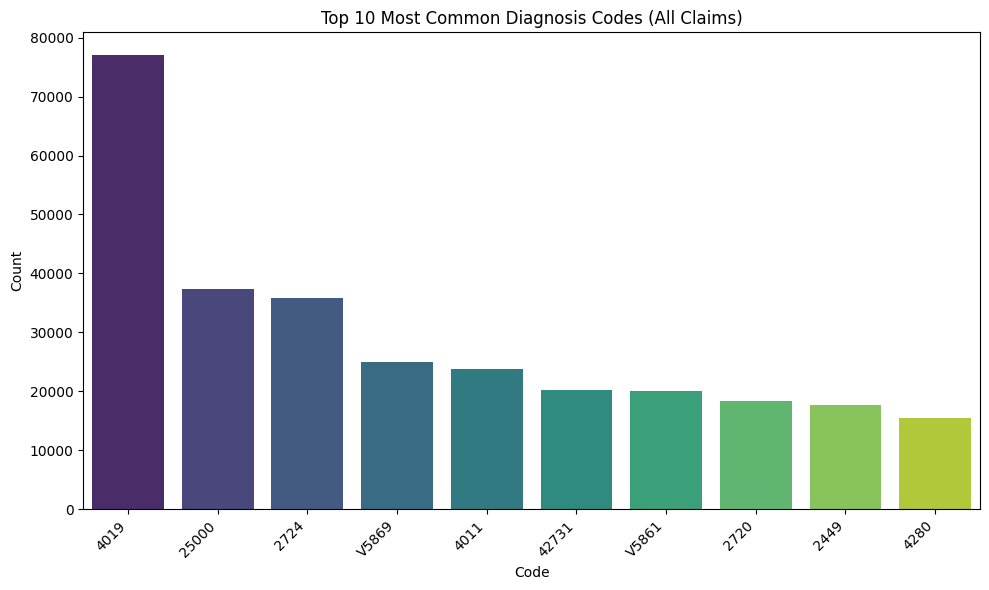

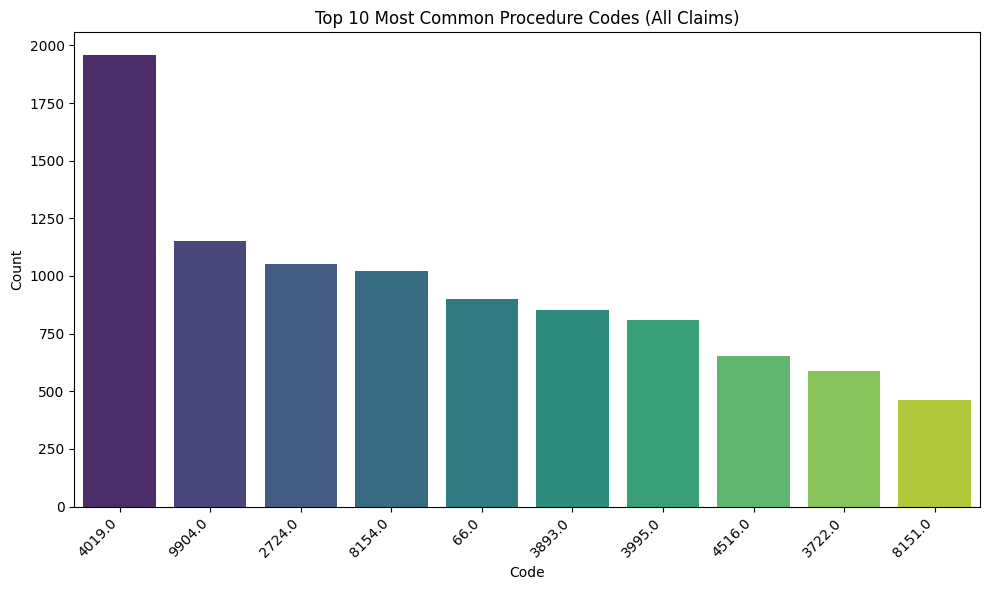


--- Fraud vs. Non-Fraud Comparison Analysis ---


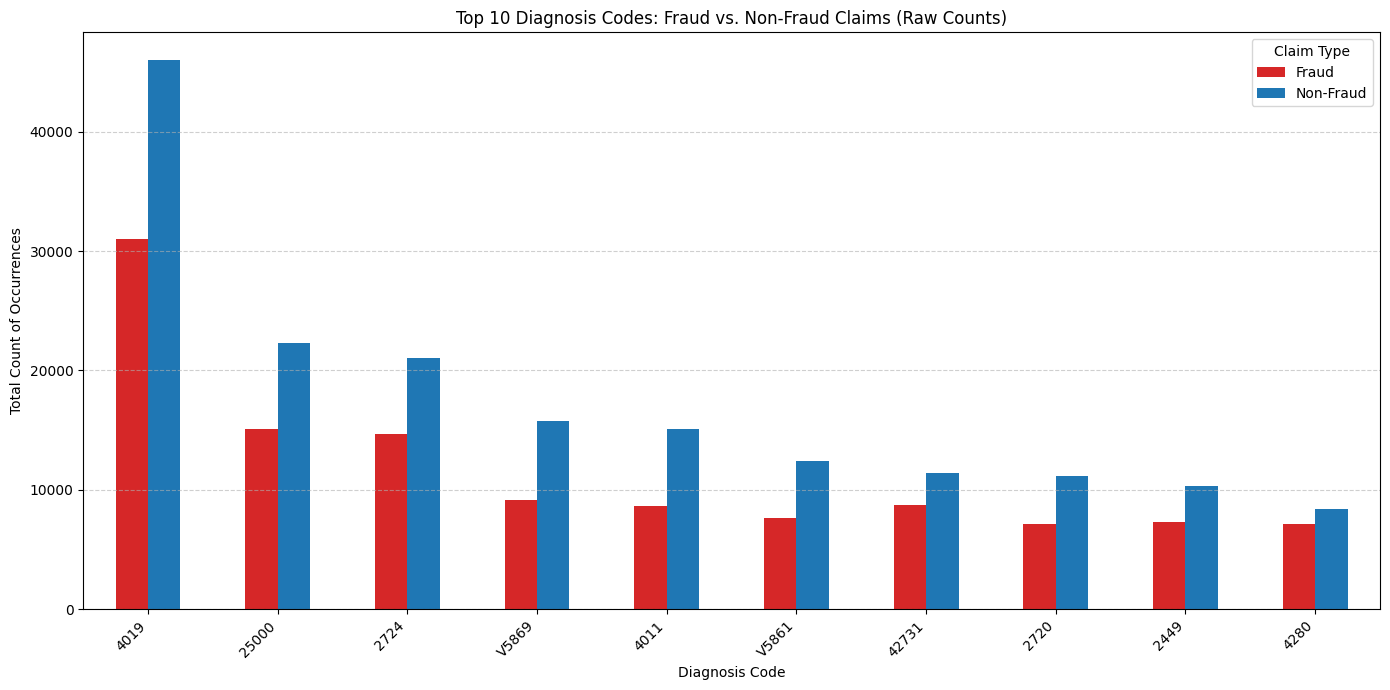

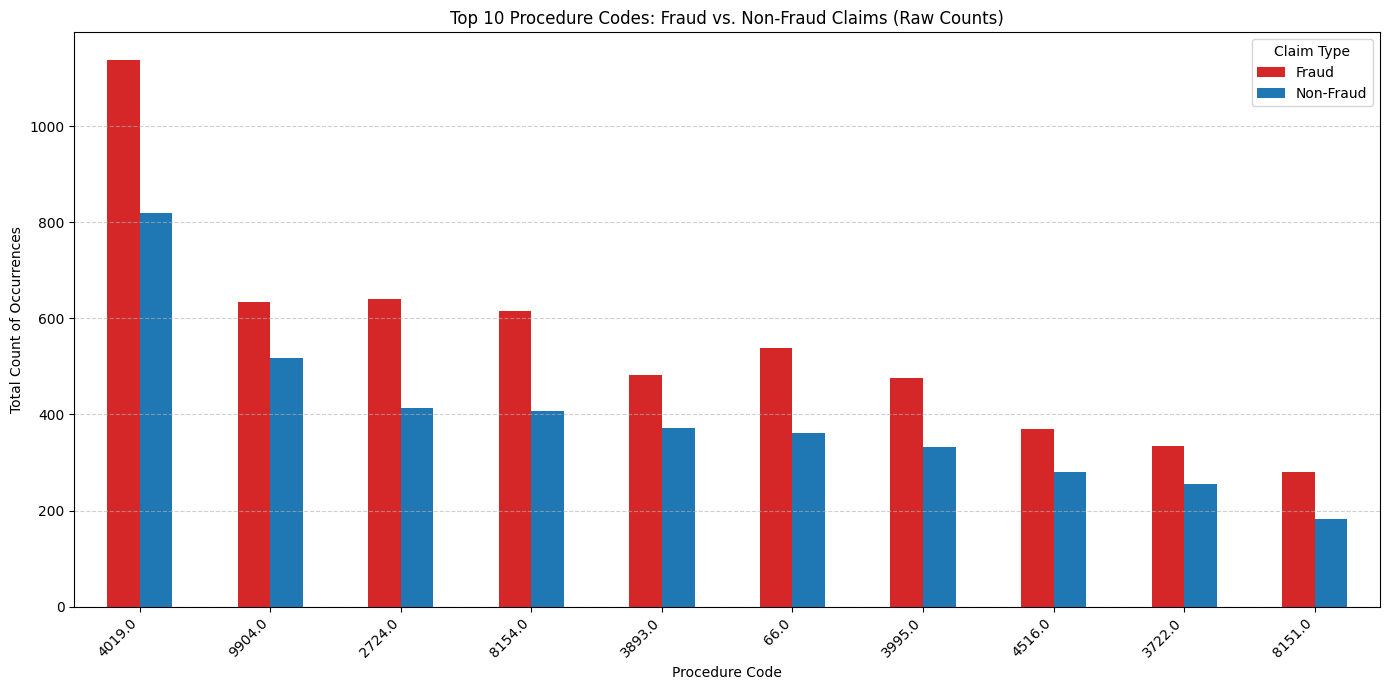

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
diagnosis_cols = [f'ClmDiagnosisCode_{i}' for i in range(1, 11)]

# Procedure codes run from 1 to 6
procedure_cols = [f'ClmProcedureCode_{i}' for i in range(1, 7)]

def plot_top_n_codes(df, code_cols, title, n=10):
    """Stacks code columns, counts occurrences, and plots the top N."""
    
    # Apply astype(str) to handle mixed types (important for Procedure Codes which are float/int/nan)
    all_codes = df[code_cols].astype(str).stack().value_counts()
    
    # Filter out NaNs if any were converted to 'nan' string
    all_codes = all_codes[all_codes.index != 'nan']
    
    # Select the top N
    top_n = all_codes.head(n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_n.index, y=top_n.values, palette="viridis")
    plt.title(f'Top {n} Most Common {title}')
    plt.xlabel('Code')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


def get_comparison_counts(df, code_list):
    """Stacks and counts all codes, filtering for a specific list of codes."""
    # Apply astype(str) and stack
    counts = df[code_list].astype(str).stack().value_counts()
    # Filter out NaNs
    counts = counts[counts.index != 'nan']
    return counts


# --- 3. Execution: Individual Plots (Overall Diagnosis and Procedure) ---

print("--- Overall Claim Code Analysis ---")
# 1. ALL Claims Diagnosis
plot_top_n_codes(engineered_df, diagnosis_cols, 'Diagnosis Codes (All Claims)')

# 2. ALL Claims Procedure
plot_top_n_codes(engineered_df, procedure_cols, 'Procedure Codes (All Claims)')


# --- 4. Execution: Fraud vs. Non-Fraud Comparison Plots ---

print("\n--- Fraud vs. Non-Fraud Comparison Analysis ---")

# --- A. Diagnosis Code Comparison ---

# 1. Determine the top 10 most frequent diagnosis codes across ALL claims
all_diag_counts = get_comparison_counts(engineered_df, diagnosis_cols)
top_10_diag_codes = all_diag_counts.head(10).index

# 2. Get counts for the top 10 codes in both groups, re-indexing to ensure common codes
fraud_diag_counts = get_comparison_counts(fraud_df, diagnosis_cols).reindex(top_10_diag_codes, fill_value=0).rename('Fraud')
non_fraud_diag_counts = get_comparison_counts(non_fraud_df, diagnosis_cols).reindex(top_10_diag_codes, fill_value=0).rename('Non-Fraud')

# 3. Combine and sort
diag_plot_df = pd.concat([fraud_diag_counts, non_fraud_diag_counts], axis=1)
diag_plot_df.index.name = 'Diagnosis_Code'
# Sort by Non-Fraud count for typical representation (since Non-Fraud is the largest group)
diag_plot_df = diag_plot_df.sort_values(by='Non-Fraud', ascending=False)

# 4. Plotting Diagnosis results
diag_plot_df.plot(kind='bar', figsize=(14, 7), color=['tab:red', 'tab:blue'])
plt.title('Top 10 Diagnosis Codes: Fraud vs. Non-Fraud Claims (Raw Counts)')
plt.xlabel('Diagnosis Code')
plt.ylabel('Total Count of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Claim Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- B. Procedure Code Comparison ---

# 1. Determine the top 10 most frequent procedure codes across ALL claims
all_proc_counts = get_comparison_counts(engineered_df, procedure_cols)
top_10_proc_codes = all_proc_counts.head(10).index

# 2. Get counts for the top 10 codes in both groups, re-indexing to ensure common codes
fraud_proc_counts = get_comparison_counts(fraud_df, procedure_cols).reindex(top_10_proc_codes, fill_value=0).rename('Fraud')
non_fraud_proc_counts = get_comparison_counts(non_fraud_df, procedure_cols).reindex(top_10_proc_codes, fill_value=0).rename('Non-Fraud')

# 3. Combine and sort
proc_plot_df = pd.concat([fraud_proc_counts, non_fraud_proc_counts], axis=1)
proc_plot_df.index.name = 'Procedure_Code'
proc_plot_df = proc_plot_df.sort_values(by='Non-Fraud', ascending=False) 

# 4. Plotting Procedure results
proc_plot_df.plot(kind='bar', figsize=(14, 7), color=['tab:red', 'tab:blue'])
plt.title('Top 10 Procedure Codes: Fraud vs. Non-Fraud Claims (Raw Counts)')
plt.xlabel('Procedure Code')
plt.ylabel('Total Count of Occurrences')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Claim Type')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [10]:
engineered_df.to_csv("data/engineered_data.csv", index=False)